# MOMARL Render Plots — Algorithm Comparison

Plots render data produced by `JusticeEnvironmentMOMA.render()`.

**Data layout expected:**
```
results/detailed_analysis/evaluation/
  happo/
    happo_w*/   ← one folder per weight vector
  mappo/
    mappo_w*/
  hasac/
    hasac_w*/
```

Each run folder contains `{algo}_idx{N}_{scenario}_{variable}.npy` files and an `objective_summary.csv`.


In [41]:

from pathlib import Path
import json
import re as _re
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from justice.util.visualizer import (
    plot_comparison_with_boxplots,
    plot_emissions_comparison_with_boxplots,
    plot_choropleth_2D_data,
    plot_stacked_area_chart_with_baseline_emissions,
    plot_median_emission_comparison_with_baseline,
    plot_regional_emissions_with_boxplots,
    plot_emission_control_rate,
)
from justice.util.data_loader import DataLoader
from justice.util.model_time import TimeHorizon
from justice.util.regional_configuration import get_region_mapping


In [67]:
# ── Configuration ─────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'justice').exists():
    REPO_ROOT = Path('/home/olaand/JUSTICE').resolve()
os.chdir(REPO_ROOT)

SCENARIO = 'SSP245'

EVAL_ROOT  = REPO_ROOT / 'results/detailed_analysis/evaluation/mohappo_welfare/'
HAPPO_ROOT = EVAL_ROOT / 'happo'
HASAC_ROOT = EVAL_ROOT / 'hasac'
MAPPO_ROOT = EVAL_ROOT / 'mappo'

BASELINE_PATH = REPO_ROOT / 'data/temporary/baseline_emissions_16.npy'

SAVE_FIGURES = True   # set True to write SVG files
OUTPUT_DIR = Path('thesis_rl/evaluation/figures/detailed_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Weight selection ──────────────────────────────────────────────────────────
# Set to a list of integer weight IDs to restrict which runs are plotted,
# or None to include all discovered runs.
HAPPO_WEIGHTS = [53, 64, 82, 99]       # e.g. [64, 82] or None for all
MAPPO_WEIGHTS = [42, 52, 88]       # e.g. [52, 80] or None for all

# Algorithm colour palette (fill / line)
HAPPO_COLOR = 'rgba(0, 63, 92, 0.25)'
HASAC_COLOR = 'rgba(255, 166, 0, 0.25)'
MAPPO_COLOR = 'rgba(187, 78, 153, 0.25)'
HAPPO_LINE  = 'rgba(0, 63, 92, 1)'
HASAC_LINE  = 'rgba(255, 166, 0, 1)'
MAPPO_LINE  = 'rgba(187, 78, 153, 1)'


PARETO_COLORS = {"HAPPO": "#033980", "HASAC": "#f6aa1e", "MAPPO": "#e15eb8"}
PARETO_MARKERS = {"HAPPO": "circle", "HASAC": "triangle-up", "MAPPO": "square"}


# ── Helpers ───────────────────────────────────────────────────────────────────
def discover_runs(algo_root: Path) -> dict[str, Path]:
    """Return {run_name: run_dir} for all weight subdirectories."""
    return {p.name: p for p in sorted(algo_root.iterdir()) if p.is_dir()}


def filter_runs(runs: dict, weights: list | None) -> dict[str, Path]:
    """Keep only runs whose name ends with _w<N> for N in *weights*.
    If *weights* is None, return all runs unchanged."""
    if weights is None:
        return runs
    keep = {f'_w{w}' for w in weights}
    return {name: path for name, path in runs.items()
            if any(name.endswith(k) for k in keep)}


def latest_export_info(run_dir: Path, scenario: str = SCENARIO) -> dict:
    """Find the highest-index export prefix inside *run_dir*."""
    candidates = list(run_dir.glob(f'*_idx*_{scenario}_global_temperature.npy'))
    if not candidates:
        raise FileNotFoundError(f'No {scenario} exports in {run_dir}')

    def _parse(path: Path):
        prefix = path.stem.rsplit(f'_{scenario}_global_temperature', 1)[0]
        idx = int(prefix.split('_idx')[-1])
        return idx, prefix

    idx, prefix = max((_parse(p) for p in candidates), key=lambda x: x[0])
    return {'idx': idx, 'prefix': prefix}


def npy_path(run_dir: Path, prefix: str, variable: str, scenario: str = SCENARIO) -> str:
    return str(run_dir / f'{prefix}_{scenario}_{variable}.npy')


In [73]:
# ── Discover runs ────────────────────────────────────────────────────
happo_runs = filter_runs(discover_runs(HAPPO_ROOT), weights=[w for w in range(3, 11)])
hasac_runs = {} #filter_runs(discover_runs(HASAC_ROOT), weights=[w for w in range(10)])
mappo_runs = {} #filter_runs(discover_runs(MAPPO_ROOT), weights=[w for w in range(10)])
happo_info = {name: latest_export_info(d) for name, d in happo_runs.items()}
hasac_info = {name: latest_export_info(d) for name, d in hasac_runs.items()}
mappo_info = {name: latest_export_info(d) for name, d in mappo_runs.items()}

happo_labels = [f'HAPPO {n} (idx {happo_info[n]["idx"]})' for n in happo_runs]
hasac_labels = [f'HASAC {n} (idx {hasac_info[n]["idx"]})' for n in hasac_runs]
mappo_labels = [f'MAPPO {n} (idx {mappo_info[n]["idx"]})' for n in mappo_runs]

all_labels = happo_labels + hasac_labels + mappo_labels
all_colors = [HAPPO_COLOR] * len(happo_runs) + [HASAC_COLOR] * len(hasac_runs) + [MAPPO_COLOR] * len(mappo_runs)
all_lines  = [HAPPO_LINE]  * len(happo_runs) + [HASAC_LINE]  * len(hasac_runs) + [MAPPO_LINE]  * len(mappo_runs)

print('REPO_ROOT  :', REPO_ROOT)
print(f'HAPPO runs : {list(happo_runs)}')
print(f'HASAC runs : {list(hasac_runs)}')
print(f'MAPPO runs : {list(mappo_runs)}')

REPO_ROOT  : /home/olaand/JUSTICE
HAPPO runs : ['happo_w10']
HASAC runs : []
MAPPO runs : []


In [76]:
## Pareto Front — Evaluation Data (all runs)
def _load_all_summaries() -> pd.DataFrame:
    """Load objective_summary.csv from every run directory (unfiltered)."""
    frames = []
    for algo, root in [('HAPPO', HAPPO_ROOT), 
                       ('HASAC', HASAC_ROOT), \
                       ('MAPPO', MAPPO_ROOT) \
                       ]:
        if not root.exists():
            continue
        for run_dir in sorted(root.iterdir()):
            csv_path = run_dir / 'objective_summary.csv'
            if csv_path.exists():
                df = pd.read_csv(csv_path, on_bad_lines='warn')
                df['run_name'] = run_dir.name
                df['algorithm'] = algo
                frames.append(df)
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames, ignore_index=True)
    combined['timestamp_utc'] = pd.to_datetime(combined['timestamp_utc'], errors='coerce')
    # Keep only the latest evaluation per run
    return (
        combined.sort_values('timestamp_utc')
        .groupby(['algorithm', 'run_name'], as_index=False)
        .tail(1)
        .sort_values(['algorithm', 'run_name'])
        .reset_index(drop=True)
    )


def is_pareto_efficient(points: np.ndarray, directions: list[str]) -> np.ndarray:
    """Return boolean mask of Pareto-efficient points.
    directions: list of 'max' or 'min' per column."""
    adjusted = points.copy()
    for j, d in enumerate(directions):
        if d == 'min':
            adjusted[:, j] = -adjusted[:, j]
    n = len(adjusted)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and np.all(adjusted[j] >= adjusted[i]) and np.any(adjusted[j] > adjusted[i]):
                mask[i] = False
                break
    return mask


def plot_pareto_front_eval(summary_df: pd.DataFrame,
                           x_col: str, y_col: str,
                           x_dir: str = 'min', y_dir: str = 'max') -> go.Figure:
    """Interactive Pareto front from evaluation summary data."""
    fig = go.Figure()
    algos = sorted(summary_df['algorithm'].unique())
    dominated_indices = []
    trace_idx = 0

    for algo in algos:
        adf = summary_df[summary_df['algorithm'] == algo].reset_index(drop=True)
        pts = adf[[x_col, y_col]].values
        color = PARETO_COLORS.get(algo, '#333')
        marker = PARETO_MARKERS.get(algo, 'circle')
        pareto = is_pareto_efficient(pts, [x_dir, y_dir]) if len(pts) > 0 else np.zeros(len(pts), dtype=bool)

        hover = [
            f"<b>{row['algorithm']} {row['run_name']}</b><br>"
            f"{x_col}: {row[x_col]:.4f}<br>{y_col}: {row[y_col]:.4f}<br>"
            f"welfare: {row.get('welfare', float('nan')):.4f}<br>"
            f"temp: {row.get('final_global_temperature', float('nan')):.3f}°C<br>"
            f"economic output: {row.get('final_global_net_economic_output', float('nan')):.4f}"
            for _, row in adf.iterrows()
        ]

        # Dominated points (hidden by default)
        dom = ~pareto
        if dom.any():
            fig.add_trace(go.Scatter(
                x=adf.loc[dom, x_col], y=adf.loc[dom, y_col],
                mode='markers',
                marker=dict(size=10, color=color, symbol=marker, opacity=0.35,
                            line=dict(width=1, color='gray')),
                name=f'{algo} (dominated)',
                customdata=[hover[i] for i in range(len(adf)) if dom[i]],
                hovertemplate='%{customdata}<extra></extra>',
                visible=False,
            ))
            dominated_indices.append(trace_idx)
            trace_idx += 1

        # Pareto points
        if pareto.any():
            fig.add_trace(go.Scatter(
                x=adf.loc[pareto, x_col], y=adf.loc[pareto, y_col],
                mode='markers',
                marker=dict(size=14, color=color, symbol=marker,
                            line=dict(width=2, color='gray')),
                name=f'{algo} (Pareto)',
                customdata=[hover[i] for i in range(len(adf)) if pareto[i]],
                hovertemplate='%{customdata}<extra></extra>',
            ))
            trace_idx += 1

    n_traces = len(fig.data)
    pareto_only = [True] * n_traces
    for i in dominated_indices:
        pareto_only[i] = False

    fig.update_layout(
        title=dict(text='Pareto Front (Evaluation)', font=dict(size=16)),
        xaxis_title=x_col.replace('_', ' ').title(),
        yaxis_title=y_col.replace('_', ' ').title(),
        legend=dict(x=0.98, y=0.05, xanchor='right', yanchor='bottom'),
        hovermode='closest',
        width=900, height=650,
        updatemenus=[dict(
            type='buttons', direction='right',
            buttons=[
                dict(args=[{'visible': pareto_only}], label='Pareto Only', method='update'),
                dict(args=[{'visible': [True] * n_traces}], label='Show All', method='update'),
            ],
            x=0.97, xanchor='right', y=1.12, yanchor='top',
        )],
    )
    return fig

In [78]:
# ── Load & plot ───────────────────────────────────────────────────────────────
PARETO_OBJECTIVES = {
    'x': 'final_global_temperature',
    'y': 'welfare',
}
pareto_df = _load_all_summaries()
print(f'Loaded {len(pareto_df)} evaluation runs')
#print(pareto_df[['algorithm', 'run_name', PARETO_OBJECTIVES['x'], PARETO_OBJECTIVES['y']]].to_string(index=False))

fig_pareto = plot_pareto_front_eval(
    pareto_df,
    x_col=PARETO_OBJECTIVES['x'],
    y_col=PARETO_OBJECTIVES['y'],
    x_dir='min',   # lower temperature is better
    y_dir='max',    # higher welfare is better
)
fig_pareto.show()
if SAVE_FIGURES:
    fig_pareto.write_image(str(OUTPUT_DIR / 'pareto_front_eval.svg'))
    print(f'Saved: {OUTPUT_DIR / "pareto_front_eval.svg"}')

Loaded 19 evaluation runs


Saved: thesis_rl/evaluation/figures/detailed_analysis/pareto_front_eval.svg


In [82]:
# ── Discover & filter runs ────────────────────────────────────────────────────
HAPPO_WEIGHTS = [11, 56]       # e.g. [64, 82] or None for all
HASAC_WEIGHTS = [] #[34, 66, 82]       # e.g. [64, 82] or None for all
MAPPO_WEIGHTS = [] #[12, 30, 60]       # e.g. [52, 80] or None for all


happo_runs = filter_runs(discover_runs(HAPPO_ROOT), HAPPO_WEIGHTS)
hasac_runs = {} #filter_runs(discover_runs(HASAC_ROOT), HASAC_WEIGHTS)
mappo_runs = {} # filter_runs(discover_runs(MAPPO_ROOT), MAPPO_WEIGHTS)
happo_info = {name: latest_export_info(d) for name, d in happo_runs.items()}
hasac_info = {name: latest_export_info(d) for name, d in hasac_runs.items()}
mappo_info = {name: latest_export_info(d) for name, d in mappo_runs.items()}

happo_labels = [f'HAPPO {n} (idx {happo_info[n]["idx"]})' for n in happo_runs]
hasac_labels = [f'HASAC {n} (idx {hasac_info[n]["idx"]})' for n in hasac_runs]
mappo_labels = [f'MAPPO {n} (idx {mappo_info[n]["idx"]})' for n in mappo_runs]

all_labels = happo_labels + hasac_labels + mappo_labels
all_colors = [HAPPO_COLOR] * len(happo_runs) + [HASAC_COLOR] * len(hasac_runs) + [MAPPO_COLOR] * len(mappo_runs)
all_lines  = [HAPPO_LINE]  * len(happo_runs) + [HASAC_LINE]  * len(hasac_runs) + [MAPPO_LINE]  * len(mappo_runs)

print('REPO_ROOT  :', REPO_ROOT)
print(f'HAPPO runs : {list(happo_runs)}')
print(f'HASAC runs : {list(hasac_runs)}')
print(f'MAPPO runs : {list(mappo_runs)}')

REPO_ROOT  : /home/olaand/JUSTICE
HAPPO runs : ['happo_w11', 'happo_w56']
HASAC runs : []
MAPPO runs : []


In [83]:

# ── Shared region-mapping loader (cached) ─────────────────────────────────────
_CLUSTER_CACHE = {}

def _load_cluster_mapping():
    if _CLUSTER_CACHE:
        return _CLUSTER_CACHE['code_to_cluster'], _CLUSTER_CACHE['clusters']
    dl = DataLoader()
    region_codes = list(dl.REGION_LIST)
    with open('data/input/9_regions.json') as f:
        rice_12 = json.load(f)
    with open('data/input/rice50_regions_dict.json') as f:
        rice_50 = json.load(f)
    code_to_cluster = {}
    for rice50_code, iso_codes in rice_50.items():
        for iso in iso_codes:
            for cluster_name, cluster_isos in rice_12.items():
                if iso in cluster_isos:
                    code_to_cluster[rice50_code] = cluster_name
                    break
            if rice50_code in code_to_cluster:
                break
    clusters = sorted(rice_12.keys())
    _CLUSTER_CACHE.update(code_to_cluster=code_to_cluster, clusters=clusters,
                          region_codes=region_codes)
    return code_to_cluster, clusters


def _cluster_color_map():
    code_to_cluster, clusters = _load_cluster_mapping()
    _base = px.colors.qualitative.Set1 + px.colors.qualitative.Dark2
    return {c: _base[i % len(_base)] for i, c in enumerate(clusters)}


def plot_grouped_control_rate_grid(
    npy_paths: list[str],
    subplot_titles: list[str],
    suptitle: str = '',
    variable_label: str = 'Rate',
    start_year: int = 2015,
    end_year: int = 2300,
    data_timestep: int = 5,
    timestep: int = 1,
    viz_start_year: int = 2015,
    viz_end_year: int = 2298,
    yaxis_range: list = None,
    ncols: int = 3,
    template: str = 'plotly_white',
) -> go.Figure:
    """Grid of per-region control-rate line plots, one subplot per weight run."""
    code_to_cluster, clusters = _load_cluster_mapping()
    region_codes = _CLUSTER_CACHE['region_codes']
    color_map = _cluster_color_map()

    th = TimeHorizon(start_year=start_year, end_year=end_year,
                     data_timestep=data_timestep, timestep=timestep)
    all_years = th.model_time_horizon
    year_cols = [y for y in all_years if viz_start_year <= y <= viz_end_year]

    n = len(npy_paths)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=subplot_titles,
                        shared_yaxes=True, shared_xaxes=True,
                        horizontal_spacing=0.03, vertical_spacing=0.08)

    legend_added = set()
    for idx, path in enumerate(npy_paths):
        row = idx // ncols + 1
        col = idx % ncols + 1

        data = np.load(path)
        if data.ndim == 3:
            data = data.mean(axis=2)

        df = pd.DataFrame(data, index=region_codes, columns=all_years)
        df = df[year_cols].copy()
        df['cluster'] = [code_to_cluster.get(c, 'Other') for c in region_codes]

        for cluster in clusters:
            sub = df[df['cluster'] == cluster]
            if sub.empty:
                continue
            vals = sub[year_cols].iloc[0].values
            show = cluster not in legend_added
            fig.add_trace(go.Scatter(
                x=year_cols, y=vals, mode='lines',
                line=dict(color=color_map[cluster], width=1.5),
                name=cluster, legendgroup=cluster,
                showlegend=show,
                hovertemplate=(f'<b>{cluster}</b><br>'
                               f'{variable_label}: %{{y:.3f}}<extra></extra>'),
            ), row=row, col=col)
            legend_added.add(cluster)

        if yaxis_range:
            fig.update_yaxes(range=yaxis_range, row=row, col=col)

    # Fit inside VS Code notebook viewport (~960px wide)
    fig.update_layout(
        title=dict(text=suptitle, font=dict(size=14)),
        template=template,
        width=960,
        height=280 * nrows + 60,
        margin=dict(l=40, r=140, t=50, b=30),
        legend=dict(title='Region', font=dict(size=10),
                    bgcolor='rgba(255,255,255,0.85)',
                    bordercolor='lightgrey', borderwidth=1,
                    x=1.01, y=1, xanchor='left'),
        hovermode='x',
    )
    fig.update_xaxes(tickfont=dict(size=9))
    fig.update_yaxes(tickfont=dict(size=9))
    # Style subplot titles
    for ann in fig['layout']['annotations']:
        ann['font'] = dict(size=11)

    return fig


In [84]:

## Emission Control Rate by Region (grid per algorithm)

for algo, runs, info in [('HAPPO', happo_runs, happo_info), ('HASAC', hasac_runs, hasac_info), ('MAPPO', mappo_runs, mappo_info)]:
    paths, titles = [], []
    for run_name, run_dir in runs.items():
        paths.append(npy_path(run_dir, info[run_name]['prefix'], 'constrained_emission_control_rate'))
        titles.append(run_name)
    fig = plot_grouped_control_rate_grid(
        npy_paths=paths,
        subplot_titles=titles,
        suptitle=f'Emission Control Rate — {algo}',
        variable_label='ECR',
        yaxis_range=[0, 1],
    )
    fig.show()
    if SAVE_FIGURES:
        fig.write_image(OUTPUT_DIR / f'{algo.lower()}_control_rate_grid.png', scale=2)


ZeroDivisionError: division by zero

In [85]:

## Savings Rate by Region (grid per algorithm)

for algo, runs, info in [('HAPPO', happo_runs, happo_info), ('HASAC', hasac_runs, hasac_info), ('MAPPO', mappo_runs, mappo_info)]:
    paths, titles = [], []
    for run_name, run_dir in runs.items():
        paths.append(npy_path(run_dir, info[run_name]['prefix'], 'constrained_savings_rate'))
        titles.append(run_name)
    fig = plot_grouped_control_rate_grid(
        npy_paths=paths,
        subplot_titles=titles,
        suptitle=f'Savings Rate — {algo}',
        variable_label='Savings Rate',
        yaxis_range=[0, 1],
    )
    fig.show()
    if SAVE_FIGURES:
        fig.write_image(OUTPUT_DIR / f'{algo.lower()}_savings_rate_grid.png', scale=2)


ZeroDivisionError: division by zero

In [50]:
## Plot 1 — Global Temperature: HASAC

happo_temp_paths = [
    npy_path(happo_runs[n], happo_info[n]['prefix'], 'global_temperature')
    for n in happo_runs
]
mappo_temp_paths = [
    npy_path(mappo_runs[n], mappo_info[n]['prefix'], 'global_temperature')
    for n in mappo_runs
]
hasac_temp_paths = [
    npy_path(hasac_runs[n], hasac_info[n]['prefix'], 'global_temperature')
    for n in hasac_runs
]

# Debug: Check what we're plotting
print(f"Number of HASAC runs: {len(hasac_runs)}")
print(f"HASAC run names: {list(hasac_runs.keys())}")
print(f"Number of HASAC paths: {len(hasac_temp_paths)}")
print(f"Number of HASAC labels: {len(hasac_labels)}")

fig_temp = plot_comparison_with_boxplots(
    data_paths=hasac_temp_paths,
    labels=['Economy focused', 'Compromise', 'Climate focused'],
    start_year=2015,
    end_year=2300,
    data_timestep=5,
    timestep=1,
    visualization_start_year=2025,
    visualization_end_year=2299,
    yaxis_range=[0.5, 5],
    plot_title='',
    output_path='.',
    xaxis_title='Year',
    yaxis_title='Global Temperature (°C)',
    template='plotly_white',
    width=1200,
    height=700,
    colors=["rgba(0,0,255,0.08)", "rgba(255,165,0,0.1)", "rgba(0,128,0,0.08)"],
    linecolors=["blue", "#FFA53E", "#72F372"],
    show_red_dashed_line=False,
    saving=False,
    show_interquartile_range=False,
    transpose_data=True,
)
# Clean up legend positioning
fig_temp.update_layout(
    legend=dict(
        x=0.92,
        y=1.08,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='lightgray',
        borderwidth=1
    )
)
fig_temp.show()


Number of HASAC runs: 3
HASAC run names: ['hasac_w34', 'hasac_w66', 'hasac_w82']
Number of HASAC paths: 3
Number of HASAC labels: 3


In [51]:
## Plot 2 — Global Emissions: HAPPO vs MAPPO

happo_em_paths = [
    npy_path(happo_runs[n], happo_info[n]['prefix'], 'emissions')
    for n in happo_runs
]
hasac_em_paths = [
    npy_path(hasac_runs[n], hasac_info[n]['prefix'], 'emissions')
    for n in hasac_runs
]
mappo_em_paths = [
    npy_path(mappo_runs[n], mappo_info[n]['prefix'], 'emissions')
    for n in mappo_runs
]

median_labels = ['SSP2-Baseline', f'Economy Focus', f'Compromise', f'Climate Focus']

fig_emissions, _ = plot_median_emission_comparison_with_baseline(
    data_paths=[str(BASELINE_PATH)] + hasac_em_paths,
    labels=median_labels,
    fill=['none', 'none', 'none', 'none'],
    path_to_output='.',
    xaxis_title='Year',
    yaxis_title='CO₂ emissions (GtCO₂/year)',
    linewidth=3,
    colour_palette=['#7F7F7F', "blue", "orange", "green"],
    template='plotly_white',
    yaxis_upper_limit=70,
    visualization_start_year=2024,
    visualization_end_year=2298,
    width=850,
    height=600,
    fontsize=15,
    saving=False,
)
fig_emissions.show()
if SAVE_FIGURES:
    fig_emissions.write_image(OUTPUT_DIR / 'global_emissions_comparison.png', scale=2)


In [52]:
## Plot 2c — Global Consumption: HASAC

hasac_cons_paths = [
    npy_path(hasac_runs[n], hasac_info[n]['prefix'], 'consumption_per_capita')
    for n in hasac_runs
]


fig_cons = plot_comparison_with_boxplots(
    data_paths=hasac_cons_paths,
    labels=['Economy Focus', 'Compromise', 'Climate Focus'],
    start_year=2015,
    end_year=2300,
    data_timestep=5,
    timestep=1,
    visualization_start_year=2025,
    visualization_end_year=2298,
    yaxis_range=None,
    plot_title='',
    output_path='.',
    xaxis_title='Year',
    yaxis_title='Global Consumption',
    template='plotly_white',
    width=1200,
    height=700,
    colors=["rgba(0,0,255,0.1)", "rgba(255,165,0,0.15)", "rgba(0,128,0,0.1)"],
    linecolors=["blue", "#FFA53E", "#72F372"],
    show_red_dashed_line=False,
    saving=False,
    show_interquartile_range=False,
    transpose_data=True,
    show_min_max=True,
    dtick=200,
)

# Clean up legend positioning
fig_cons.update_layout(
    legend=dict(
        x=0.82,
        y=0.98,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='lightgray',
        borderwidth=1
    )
)

fig_cons.show()
if SAVE_FIGURES:
    fig_cons.write_image(OUTPUT_DIR / 'consumption_comparison.png', scale=2)

Data is 3D
Shape of data:  (57, 286, 15)
Shape of data after summing:  (286, 15)
Data is 3D
Shape of data:  (57, 286, 15)
Shape of data after summing:  (286, 15)
Data is 3D
Shape of data:  (57, 286, 15)
Shape of data after summing:  (286, 15)


In [53]:
## Plot 2b — Global Net Economic Output: HASAC

hasac_neo_paths = [
    npy_path(hasac_runs[n], hasac_info[n]['prefix'], 'net_economic_output')
    for n in hasac_runs
]

# Simplified labels for cleaner legend
neo_labels = [f'Weight {list(hasac_runs.keys())[i].split("_w")[-1]}' for i in range(len(hasac_runs))]

fig_neo = plot_comparison_with_boxplots(
    data_paths=hasac_neo_paths,
    labels=['Economy Focus', 'Compromise', 'Climate Focus'],
    start_year=2015,
    end_year=2300,
    data_timestep=5,
    timestep=1,
    visualization_start_year=2025,
    visualization_end_year=2298,
    yaxis_range=None,
    plot_title='',
    output_path='.',
    xaxis_title='Year',
    yaxis_title='Global Net Economic Output',
    template='plotly_white',
    width=1200,
    height=700,
    colors=["rgba(0,0,255,0.1)", "rgba(255,165,0,0.15)", "rgba(0,128,0,0.1)"],
    linecolors=["blue", "#FFA53E", "#72F372"],
    show_red_dashed_line=False,
    saving=False,
    show_interquartile_range=False,
    transpose_data=True,
    show_min_max=True,
    dtick=200,
)

# Clean up legend positioning
fig_neo.update_layout(
    legend=dict(
        x=0.02,
        y=0.98,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='lightgray',
        borderwidth=1
    )
)

fig_neo.show()
if SAVE_FIGURES:
    fig_neo.write_image(OUTPUT_DIR / 'net_economic_output_comparison.png', scale=2)

Data is 3D
Shape of data:  (57, 286, 15)
Shape of data after summing:  (286, 15)
Data is 3D
Shape of data:  (57, 286, 15)
Shape of data after summing:  (286, 15)
Data is 3D
Shape of data:  (57, 286, 15)
Shape of data after summing:  (286, 15)


## Plot 3 — Median Emission Pathways vs Baseline

Best HAPPO run vs best MAPPO run, compared against the SSP2-4.5 baseline.

> **Best run** = the run whose `objective_summary.csv` records the highest `welfare`.  
> Falls back to the first discovered run if the CSV is missing.


In [54]:
def _best_run(runs: dict, info: dict) -> str:
    """Return the name of the run with highest welfare, or the first run."""
    scores = {}
    for name, run_dir in runs.items():
        csv = run_dir / 'objective_summary.csv'
        if csv.exists():
            df = pd.read_csv(csv)
            if 'welfare' in df.columns:
                scores[name] = df['welfare'].max()
                print(name, df['welfare'])
    return max(scores, key=scores.get) if scores else next(iter(runs))


best_happo = _best_run(happo_runs, happo_info)
best_hasac = _best_run(hasac_runs, hasac_info)
best_mappo = _best_run(mappo_runs, mappo_info)

print(f'Best HAPPO run: {best_happo}')
print(f'Best HASAC run: {best_hasac}')
print(f'Best MAPPO run: {best_mappo}')

if BASELINE_PATH.exists():
    median_paths = [
        str(BASELINE_PATH),
        npy_path(happo_runs[best_happo], happo_info[best_happo]['prefix'], 'emissions'),
        npy_path(hasac_runs[best_hasac], hasac_info[best_hasac]['prefix'], 'emissions'),
        npy_path(mappo_runs[best_mappo], mappo_info[best_mappo]['prefix'], 'emissions'),
    ]
    median_labels = ['SSP2-Baseline', f'HAPPO {best_happo}', f'HASAC {best_hasac}', f'MAPPO {best_mappo}']

    fig_median, _ = plot_median_emission_comparison_with_baseline(
        data_paths=median_paths,
        labels=median_labels,
        fill=['none', 'none', 'none', 'none'],
        path_to_output='.',
        xaxis_title='Year',
        yaxis_title='CO₂ emissions (GtCO₂/year)',
        linewidth=3,
        colour_palette=['#7F7F7F', HAPPO_LINE, HASAC_LINE, MAPPO_LINE],
        template='plotly_white',
        yaxis_upper_limit=70,
        visualization_start_year=2024,
        visualization_end_year=2299,
        width=850,
        height=600,
        fontsize=15,
        saving=False,
    )
    fig_median.show()
else:
    print(f'Baseline not found at {BASELINE_PATH}. Set BASELINE_PATH in the config cell.')


happo_w3 0   -206.559123
Name: welfare, dtype: float64
happo_w65 0   -164.906025
Name: welfare, dtype: float64
happo_w86 0   -159.176998
Name: welfare, dtype: float64
hasac_w34 0   -158.492287
Name: welfare, dtype: float64
hasac_w66 0   -242.273898
Name: welfare, dtype: float64
hasac_w82 0   -236.451691
Name: welfare, dtype: float64
mappo_w12 0   -165.09585
Name: welfare, dtype: float64
mappo_w30 0   -171.401287
Name: welfare, dtype: float64
mappo_w60 0   -173.670669
Name: welfare, dtype: float64
Best HAPPO run: happo_w86
Best HASAC run: hasac_w34
Best MAPPO run: mappo_w12


## Plot 4 — Regional Emission Envelopes: Best HAPPO vs Best MAPPO

Per-region emission envelopes for the best run of each algorithm.  
Adjust `REGION_INDICES` as needed (paper uses RICE-50 indices `[9, 28, 54, 43]`).


In [55]:
## Plot 4 — Regional Emissions: best HAPPO vs best MAPPO

REGION_INDICES = [9, 28, 54, 43]

happo_em_path = npy_path(happo_runs[best_happo], happo_info[best_happo]['prefix'], 'emissions')
mappo_em_path = npy_path(mappo_runs[best_mappo], mappo_info[best_mappo]['prefix'], 'emissions')

for region in REGION_INDICES:
    fig = plot_regional_emissions_with_boxplots(
        utilitarian_path=happo_em_path,    # HAPPO plays the role of "utilitarian"
        prioritarian_path=mappo_em_path,   # MAPPO plays the role of "prioritarian"
        start_year=2015,
        end_year=2300,
        data_timestep=5,
        timestep=1,
        visualization_start_year=2025,
        visualization_end_year=2100,
        region_index=region,
        yaxis_range=[0, 15],
        opacity=0.07,
        plot_title=f'Emissions — HAPPO ({best_happo}) vs MAPPO ({best_mappo}) | Region {region}',
        xaxis_title='Year',
        yaxis_title='Emissions (GtCO₂/year)',
        template='plotly_white',
        width=800,
        height=600,
        color_palette=[HAPPO_LINE, MAPPO_LINE],
        output_path='.',
        saving=False,
    )
    #fig.show()


In [56]:

## Plot 5 — Emission Control Rate Choropleth (multi-year grid per run)

from justice.util.visualizer import process_2D_regional_data_for_choropleth_plot_v2_opt, min_max_scaler
from justice.util.data_loader import DataLoader
from justice.util.model_time import TimeHorizon

def plot_choropleth_years_grid(
    npy_file: str,
    years: list,
    run_title: str,
    colourmap=px.colors.sequential.Reds,
    projection: str = 'natural earth',
    data_label: str = 'Emission Control Rate',
    data_normalization: bool = True,
    width_per_col: int = 400,
    height: int = 300,
):
    """Create a single figure with one choropleth per year, laid out in a row."""
    dl = DataLoader()
    region_list = dl.REGION_LIST
    th = TimeHorizon(start_year=2015, end_year=2300, data_timestep=5, timestep=1)
    list_of_years = th.model_time_horizon

    data = np.load(npy_file)
    if data.ndim == 3:
        data = data.mean(axis=2)

    # Calculate global min/max from the ENTIRE dataset for consistent normalization
    global_min = data.min()
    global_max = data.max()

    # Process country data for each year
    year_dfs = {}
    for yr in years:
        year_dfs[yr] = process_2D_regional_data_for_choropleth_plot_v2_opt(
            region_list=region_list,
            data=data,
            list_of_years=list_of_years,
            year_to_visualize=yr,
            data_label=data_label,
            region_to_country_mapping='data/input/rice50_regions_dict.json',
        )
    if data_normalization:
        for yr in years:
            vals = year_dfs[yr][data_label].values.reshape(-1, 1)
            year_dfs[yr][data_label] = min_max_scaler(vals, global_min, global_max)

    n = len(years)
    specs = [[{"type": "choropleth"}] * n]
    fig = make_subplots(
        rows=1, cols=n,
        specs=specs,
        subplot_titles=[str(yr) for yr in years],
        horizontal_spacing=0.02,
    )

    # Build a discrete colorscale list from the px sequential palette
    n_colors = len(colourmap)
    colorscale = [(i / (n_colors - 1), colourmap[i]) for i in range(n_colors)]

    for col_idx, yr in enumerate(years):
        df = year_dfs[yr]
        show_cb = col_idx == n - 1  # only rightmost column gets colorbar
        trace = go.Choropleth(
            locations=df['CountryCode'],
            z=df[data_label],
            text=df['CountryName'],
            hovertemplate='<b>%{text}</b><br>' + data_label + ': %{z:.3f}<extra></extra>',
            colorscale=colorscale,
            zmin=0 if data_normalization else global_min,
            zmax=1 if data_normalization else global_max,
            showscale=show_cb,
            colorbar=dict(
                title=data_label,
                x=1.01,
                thickness=12,
                len=0.8,
                tickvals=[0, 0.25, 0.5, 0.75, 1] if data_normalization else [global_min, (global_min + global_max) / 2, global_max],
                ticktext=['0%', '25%', '50%', '75%', '100%'] if data_normalization else [f'{global_min:.2f}', f'{(global_min + global_max) / 2:.2f}', f'{global_max:.2f}'],
            ) if show_cb else None,
            marker_line_color='white',
            marker_line_width=0.3,
        )
        fig.add_trace(trace, row=1, col=col_idx + 1)
        geo_key = 'geo' if col_idx == 0 else f'geo{col_idx + 1}'
        fig.update_layout(**{geo_key: dict(
            projection_type=projection,
            showframe=False,
            showcoastlines=True,
            coastlinecolor='lightgrey',
            showland=True,
            landcolor='#f0f0f0',
            showocean=True,
            oceancolor='#e8f4f8',
            bgcolor='white',
        )})

    fig.update_layout(
        title=dict(text=run_title, x=0.5, xanchor='center', font=dict(size=13)),
        template='plotly_white',
        width=width_per_col * n,
        height=height + 60,
        margin=dict(l=10, r=80, t=50, b=10),
    )
    # Style subplot year labels
    for ann in fig['layout']['annotations']:
        ann['font'] = dict(size=11)

    return fig

In [57]:
years_to_visualize = [2045, 2075, ]

for algo, runs, info in [('HASAC', hasac_runs, hasac_info)]:
    algo_root = HASAC_ROOT if algo == 'HASAC' else MAPPO_ROOT
    for run_name, run_dir in runs.items():
        npy_file = str(run_dir / f'{info[run_name]["prefix"]}_{SCENARIO}_constrained_emission_control_rate.npy')
        fig = plot_choropleth_years_grid(
            npy_file=npy_file,
            years=years_to_visualize,
            run_title=f'Emission Control Rate — MO{algo} {run_name}',
            colourmap=px.colors.sequential.Reds,
            projection='natural earth',
            data_normalization=False,
            data_label = 'ECR',
        )
        fig.show()
        if SAVE_FIGURES:
            out = OUTPUT_DIR / "maps" / f'ecr_{algo}_{run_name}.png'
            fig.write_image(str(out), scale=2)
            print(f'Saved: {out}')


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/ecr_HASAC_hasac_w34.png


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/ecr_HASAC_hasac_w66.png


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/ecr_HASAC_hasac_w82.png


In [58]:
years_to_visualize = [2100]

for algo, runs, info in [('HASAC', hasac_runs, hasac_info)]:
    algo_root = HASAC_ROOT if algo == 'HASAC' else MAPPO_ROOT
    for run_name, run_dir in runs.items():
        npy_file = str(run_dir / f'{info[run_name]["prefix"]}_{SCENARIO}_constrained_savings_rate.npy')
        fig = plot_choropleth_years_grid(
            npy_file=npy_file,
            years=years_to_visualize,
            run_title=f'Savings Rate — MO{algo} {run_name}',
            data_label='SR',
            colourmap=px.colors.sequential.Blues,
            projection='natural earth',
            data_normalization=False,
        )
        fig.show()
        if SAVE_FIGURES:
            out = OUTPUT_DIR / "maps" / f'savings_rate_{algo}_{run_name}.png'
            fig.write_image(str(out), scale=2)
            print(f'Saved: {out}')

Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/savings_rate_HASAC_hasac_w34.png


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/savings_rate_HASAC_hasac_w66.png


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/savings_rate_HASAC_hasac_w82.png


## Consumption Per Capita by Region

Regional consumption per capita maps showing how different policies affect economic welfare distribution across regions and time periods. Higher values (darker green) indicate better consumption levels.

In [59]:
years_to_visualize = [2045, 2100, 2200]

for algo, runs, info in [('HASAC', hasac_runs, hasac_info)]:
    algo_root = HASAC_ROOT if algo == 'HASAC' else MAPPO_ROOT
    for run_name, run_dir in runs.items():
        npy_file = str(run_dir / f'{info[run_name]["prefix"]}_{SCENARIO}_consumption_per_capita.npy')
        fig = plot_choropleth_years_grid(
            npy_file=npy_file,
            years=years_to_visualize,
            run_title=f'Consumption Per Capita — MO{algo} {run_name}',
            data_label='Consumption Per Capita',
            colourmap=px.colors.sequential.YlGn,
            projection='natural earth',
            data_normalization=False,
            width_per_col=300,
            height=250,
        )
        fig.show()
        if SAVE_FIGURES:
            out = OUTPUT_DIR / "maps" / f'consumption_per_capita_{algo}_{run_name}.png'
            out.parent.mkdir(parents=True, exist_ok=True)
            fig.write_image(str(out), scale=2)
            print(f'Saved: {out}')

Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/consumption_per_capita_HASAC_hasac_w34.png


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/consumption_per_capita_HASAC_hasac_w66.png


Saved: thesis_rl/evaluation/figures/detailed_analysis/maps/consumption_per_capita_HASAC_hasac_w82.png


In [60]:
## Plot 6 — Regional Emission Stacked-Area Chart (best HAPPO vs best MAPPO)

region_dict = json.load(open(REPO_ROOT / 'data/input/9_regions.json'))

REGION_COLOURS = [
    'rgb(149,150,160)',  'rgb(149,150,160,0.2)',
    'rgb(247,129,191)',  'rgb(247,129,191,0.2)',
    'rgb(166,86,40)',    'rgb(166,86,40,0.2)',
    'rgb(255,255,51)',   'rgb(255,255,51,0.2)',
    'rgb(255,127,0)',    'rgb(255,127,0,0.2)',
    'rgb(152,78,163)',   'rgb(152,78,163,0.2)',
    'rgb(77,175,74)',    'rgb(77,175,74,0.2)',
    'rgb(55,126,184)',   'rgb(55,126,184,0.2)',
    'rgb(228,26,28)',    'rgb(228,26,28,0.2)',
]
REGIONAL_ORDER = [
    'Rest of the World', 'Rest of the World_abated',
    'Europe', 'Europe_abated',
    'Gulf Countries', 'Gulf Countries_abated',
    'South and Southeast Asia', 'South and Southeast Asia_abated',
    'Other High Income', 'Other High Income_abated',
    'Sub-Saharan Africa', 'Sub-Saharan Africa_abated',
    'China', 'China_abated',
    'India', 'India_abated',
    'United States', 'United States_abated',
]

for algo, runs, info, algo_root in [
    ('HASAC', hasac_runs, hasac_info, HASAC_ROOT),
    #('MAPPO', mappo_runs, mappo_info, MAPPO_ROOT),
]:
    for run_name in runs:
        fig, _, _ = plot_stacked_area_chart_with_baseline_emissions(
            variable_name='emissions',
            filetype='.npy',
            path_to_data=str(algo_root),
            baseline_emissions_path=str(BASELINE_PATH),
            input_data=[f'{run_name}/{info[run_name]["prefix"]}'],
            output_titles=[f'{algo} {run_name}'],
            scenario_list=[SCENARIO],
            title=f'Regional Emissions — {algo} {run_name} vs Baseline',
            xaxis_label='Year',
            yaxis_label='',
            height=600,
            width=850,
            visualization_start_year=2025,
            visualization_end_year=2100,
            plot_title=' ',
            groupnorm='percent',
            colour_palette=REGION_COLOURS,
            region_dict=region_dict,
            saving=False,
            yaxis_lower_limit=0,
            yaxis_upper_limit=16,
            regional_order=REGIONAL_ORDER,
        )
        fig.show()


Loading data for:  SSP245  -  hasac_w34/hasac_idx0
Baseline emissions shape:  (57, 286, 15)
Data shape:  (57, 286, 15)
Region list:  ['Rest of the World', 'Europe', 'Sub-Saharan Africa', 'Gulf Countries', 'Other High Income', 'South and Southeast Asia', 'China', 'India', 'United States']


Loading data for:  SSP245  -  hasac_w66/hasac_idx0
Baseline emissions shape:  (57, 286, 15)
Data shape:  (57, 286, 15)
Region list:  ['Rest of the World', 'Europe', 'Sub-Saharan Africa', 'Gulf Countries', 'Other High Income', 'South and Southeast Asia', 'China', 'India', 'United States']


Loading data for:  SSP245  -  hasac_w82/hasac_idx0
Baseline emissions shape:  (57, 286, 15)
Data shape:  (57, 286, 15)
Region list:  ['Rest of the World', 'Europe', 'Sub-Saharan Africa', 'Gulf Countries', 'Other High Income', 'South and Southeast Asia', 'China', 'India', 'United States']


In [61]:
# ── Discover & filter runs ────────────────────────────────────────────────────
# For all weights: [w for w in range(100)]  
HAPPO_WEIGHTS = [w for w in range(100)]  # [3, 60, 65, 50, 87]      # e.g. [64, 82] or None for all
MAPPO_WEIGHTS = [w for w in range(100)]  # [12, 56]       # e.g. [52, 80] or None for all
HASAC_WEIGHTS = [w for w in range(100)]  # [27, 66, 82]       # e.g. [64, 82] or None for all
# HAPPO_WEIGHTS = [3, 22, 46]       # e.g. [64, 82] or None for all
# MAPPO_WEIGHTS = [12, 30, 60]       # e.g. [52, 80] or None for all

happo_runs = filter_runs(discover_runs(HAPPO_ROOT), HAPPO_WEIGHTS)
hasac_runs = filter_runs(discover_runs(HASAC_ROOT), HASAC_WEIGHTS)
mappo_runs = filter_runs(discover_runs(MAPPO_ROOT), MAPPO_WEIGHTS)
happo_info = {name: latest_export_info(d) for name, d in happo_runs.items()}
hasac_info = {name: latest_export_info(d) for name, d in hasac_runs.items()}
mappo_info = {name: latest_export_info(d) for name, d in mappo_runs.items()}

happo_labels = [f'HAPPO {n} (idx {happo_info[n]["idx"]})' for n in happo_runs]
hasac_labels = [f'HASAC {n} (idx {hasac_info[n]["idx"]})' for n in hasac_runs]
mappo_labels = [f'MAPPO {n} (idx {mappo_info[n]["idx"]})' for n in mappo_runs]

all_labels = happo_labels + hasac_labels + mappo_labels
all_colors = [HAPPO_COLOR] * len(happo_runs) + [HASAC_COLOR] * len(hasac_runs) + [MAPPO_COLOR] * len(mappo_runs)
all_lines  = [HAPPO_LINE]  * len(happo_runs) + [HASAC_LINE]  * len(hasac_runs) + [MAPPO_LINE]  * len(mappo_runs)

print('REPO_ROOT  :', REPO_ROOT)
print(f'HAPPO runs : {list(happo_runs)}')
print(f'HASAC runs : {list(hasac_runs)}')
print(f'MAPPO runs : {list(mappo_runs)}')

REPO_ROOT  : /home/olaand/JUSTICE
HAPPO runs : ['happo_w0', 'happo_w1', 'happo_w10', 'happo_w11', 'happo_w12', 'happo_w13', 'happo_w14', 'happo_w15', 'happo_w16', 'happo_w17', 'happo_w18', 'happo_w19', 'happo_w2', 'happo_w20', 'happo_w21', 'happo_w22', 'happo_w23', 'happo_w24', 'happo_w25', 'happo_w26', 'happo_w27', 'happo_w28', 'happo_w29', 'happo_w3', 'happo_w30', 'happo_w31', 'happo_w32', 'happo_w33', 'happo_w34', 'happo_w35', 'happo_w36', 'happo_w37', 'happo_w38', 'happo_w39', 'happo_w4', 'happo_w40', 'happo_w41', 'happo_w42', 'happo_w43', 'happo_w44', 'happo_w45', 'happo_w46', 'happo_w47', 'happo_w48', 'happo_w49', 'happo_w5', 'happo_w50', 'happo_w51', 'happo_w52', 'happo_w53', 'happo_w54', 'happo_w55', 'happo_w56', 'happo_w57', 'happo_w58', 'happo_w59', 'happo_w6', 'happo_w60', 'happo_w61', 'happo_w62', 'happo_w63', 'happo_w64', 'happo_w65', 'happo_w66', 'happo_w67', 'happo_w68', 'happo_w69', 'happo_w7', 'happo_w70', 'happo_w71', 'happo_w72', 'happo_w73', 'happo_w74', 'happo_w75'

,algorithm,run_name,welfare,final_global_net_economic_output,final_global_temperature,years_above_temperature_threshold,num_agents,num_objectives
83,HAPPO,happo_w84,-141.548607,475.380139,2.710467,242,12,2
81,HAPPO,happo_w82,-142.946879,488.977047,2.394713,239,12,2
128,HASAC,hasac_w31,-143.140687,1612.998082,5.636492,251,12,2
86,HAPPO,happo_w87,-143.192130,641.944847,2.597957,239,12,2
84,HAPPO,happo_w85,-144.488393,443.816906,2.586008,239,12,2
76,HAPPO,happo_w78,-144.496133,411.862077,2.610499,240,12,2
59,HAPPO,happo_w62,-144.792199,523.153565,2.633602,241,12,2
80,HAPPO,happo_w81,-145.144483,493.656435,2.603467,239,12,2
285,MAPPO,mappo_w78,-145.448888,939.389198,2.700760,241,12,2
127,HASAC,hasac_w30,-146.255950,1176.246791,6.488523,250,12,2


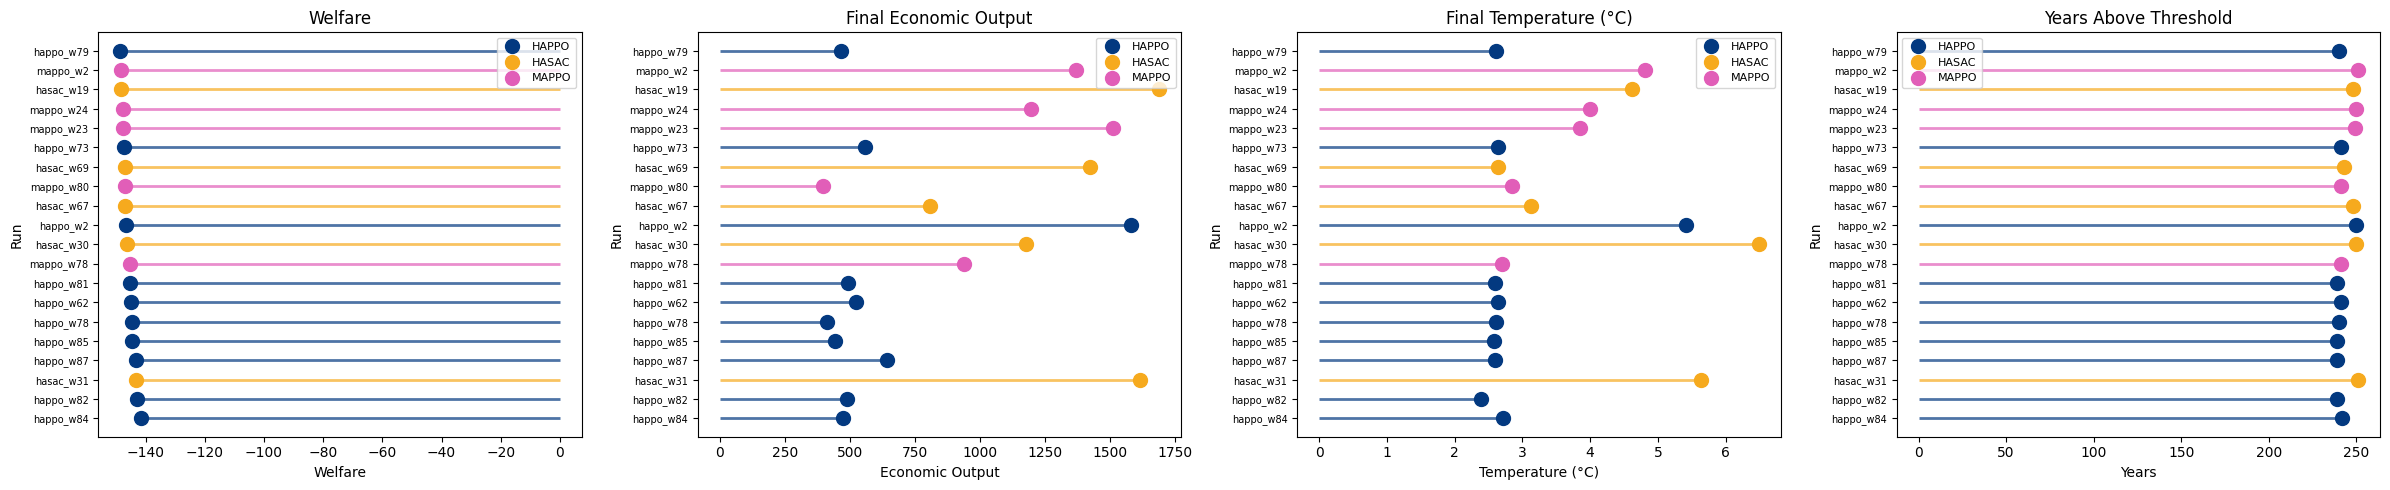

In [62]:
## Plot 7 — Objective Summary: HAPPO vs MAPPO

def _load_summary(runs: dict, algo: str) -> pd.DataFrame:
    frames = []
    for run_name, run_dir in runs.items():
        csv = run_dir / 'objective_summary.csv'
        if csv.exists():
            df = pd.read_csv(csv)
            df['run_name'] = run_name
            df['algorithm'] = algo
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


happo_summary = _load_summary(happo_runs, 'HAPPO')
hasac_summary = _load_summary(hasac_runs, 'HASAC')
mappo_summary = _load_summary(mappo_runs, 'MAPPO')
all_summary   = pd.concat([happo_summary, hasac_summary, mappo_summary], ignore_index=True)

all_summary['timestamp_utc'] = pd.to_datetime(all_summary['timestamp_utc'], errors='coerce')
all_summary["weight"] = all_summary['run_name'].str.extract(r'(\d+)').astype(float)
latest_summary = (
    all_summary.sort_values('run_name')
    .groupby(['run_name'], as_index=False)
    .tail(1)
    .sort_values([ "welfare"], ascending=False)
)[:20]

display(
    latest_summary[[
        'algorithm', 'run_name',
        'welfare', 'final_global_net_economic_output', 'final_global_temperature', 'years_above_temperature_threshold',
        'num_agents', 'num_objectives',
    ]]
)

BAR_METRICS = [
    ('welfare',                       'Welfare',                    'Welfare'),
    ('final_global_net_economic_output', 'Final Economic Output',      'Economic Output'),
    ('final_global_temperature',      'Final Temperature (°C)',     'Temperature (°C)'),
    ('years_above_temperature_threshold', 'Years Above Threshold', 'Years'),
]
palette = {"HAPPO": "#033980", "HASAC": "#f6aa1e", "MAPPO": "#e15eb8",}

fig, axes = plt.subplots(1, len(BAR_METRICS), figsize=(6 * len(BAR_METRICS), 5))
for ax, (metric, title, y_label) in zip(np.atleast_1d(axes), BAR_METRICS):
    if metric not in latest_summary.columns:
        ax.set_visible(False)
        continue
    for _, weight in latest_summary.iterrows():
        color = palette.get(weight['algorithm'], 'gray')
        ax.hlines(weight['run_name'], 0, weight[metric], color=color, linewidth=2, alpha=0.7)
        ax.plot(weight[metric], weight['run_name'], 'o', color=color, markersize=10, label=weight['algorithm'])
    ax.set_title(title)
    ax.set_xlabel(y_label)
    ax.set_ylabel('Run')
    ax.tick_params(axis='y', labelsize=7)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8)

plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / 'objective_summary_comparison.png', dpi=600, bbox_inches='tight')
plt.show()
